# RadCAT 
Radar column aircraft track code. Within this code aircraft time and position will be compared against radar data and then appropriate matches bewtween the radar sweeps, azimuths, and ranges will be made so that a representation of the most up to date environment around the aircraft can be displayed as a time series. This can allow for further comparisons between in-situ measured observations from the Citation research jet and the ground based C-SAPR radar observations during the MC3E field campaign. 

In [1]:
# Time to code up some BS 
import pyart
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.feature as cfeature
import xarray as xr
import os
import pandas as pd
import time
import io
import cmweather
from datetime import datetime
import numpy as np
import matplotlib.ticker as ticker
import ipywidgets as widgets
from IPython.display import display
import matplotlib.transforms as mtransforms


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



In [ ]:
# OLD CODE DO NOT USE 

#===============================================================
# This block of code looks at both radar times and aircraft times
# and generates a surrounding environment radar scan based on
# the location and timing of the aircraft during observations.
#===============================================================

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append(datetime.strptime(radar_files[x].name[21:36], "%Y%m%d.%H%M%S").timestamp())

radar_file_times = np.array(radar_file_times)

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Aircraft.nc')

# Generate empty data array for radar sweeps to be populated in
times = cloud_micro.Time.data  
sweep_options = ['below', 'in', 'above']
cloud_micro_radar = xr.DataArray(
    data = np.nan, 
    dims=["time", "sweep"],
    coords={"time": times, "sweep": sweep_options})

for number_files in range(len(radar_file_times) - 1):
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)
    
    #===================================================================================
    # Find valid aircraft times that overlap the end of the max sweep of the first radar 
    # data file to the end of the max sweep in the second radar file.
    #===================================================================================
    
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    for time in range(len(cit_time)):
        cit_time_ind = datetime.strptime(cit_time[time][0:19], "%Y-%m-%dT%H:%M:%S").timestamp()
        if cit_time_ind >= file_start_time and cit_time_ind <= file_end_time:
            valid_time_list = np.append(valid_time_list, cit_time[time])

            #===================================================================================
            # Find which sweep the aircraft is in and then what appropriate radar file should be
            # Used for that given sweep.
            #===================================================================================

            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cit_lat[time], cit_lon[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
    
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            
            if (sweep_time + radar_file_times[number_files + 1]) <= cit_time_ind:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cit_lat[time], cit_lon[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
                
                # Check to see if an above and below scan can be provided or if only a center scan can be returned
                if sweep == 0 or sweep == data2.nsweeps:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan
                    
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
                
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cit_lat[time], cit_lon[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cit_alt[time])))
                
                # Check to see if an above and below scan can be provided or if only a center scan can be returned
                if sweep == 0 or sweep == data1.nsweeps:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan
                    
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]

            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            reflec_data_tot.append(reflec_data)
            valid_time_tot.append(cit_time[time])

reflec_data_tot = np.array(reflec_data_tot)
valid_time_tot = np.array(valid_time_tot)

In [17]:
# ASSOCIATED SUDO RHI SCAN AND REFLECTIVITY TIME SERIES CODE

#===============================================================
# This block of code looks at both radar times and aircraft times
# and generates a surrounding environment radar scan based on
# the location and timing of the aircraft during observations.
#===============================================================

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append((int(radar_files[x].name[30:36][0:2]) * 3600) + (int(radar_files[x].name[30:36][2:4]) * 60) + (int(radar_files[x].name[30:36][4:6])))

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Aircraft.nc')

# Generate empty data array for radar sweeps to be populated in
times = cloud_micro.Time.data  
sweep_options = ['below', 'in', 'above']
cloud_micro_radar = xr.DataArray(
    data = np.nan, 
    dims=["Time", "sweep"],
    coords={"Time": times, "sweep": sweep_options})

# Looping through radar files to populate the radar sweep array with data 
for number_files in range(len(radar_file_times) - 1):
    
    # Read in of both data files that will be later compared against aircraft times
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)

    # Code to find the start and end range of times that aircraft data can be compared against 
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    # Looping through every tenth aircraft time
    for time in range(len(cloud_micro_radar.Time.data)):

        # If statement to find which aircraft times are within the radar time range 
        if cloud_micro_radar.Time.data[time] >= file_start_time and cloud_micro_radar.Time.data[time] < file_end_time:

            # Find the sweep that is appropriate to the aircrafts position 
            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))

            # Find if the sweep is within a valid time range or not
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            if (sweep_time + radar_file_times[number_files + 1]) <= cloud_micro_radar.Time.data[time]:
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data2.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
            
                # Saving of sudo RHI plots for analysis to make sure code is performing correct actions
                radar_lat = data2.latitude['data'][0]
                radar_lon = data2.longitude['data'][0]
    
                radar_azimuth = pyart.util.for_azimuth(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time])
                aircraft_distance = pyart.util.sphere_distance(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time]) / 1000
                
                display = pyart.graph.RadarMapDisplay(data2)
                fig, ax = plt.subplots(figsize=(12, 10))
                display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                               ax = ax, 
                               target_azimuth = radar_azimuth, 
                               vmin = -30,
                               vmax = 70,
                               cmap = 'ChaseSpectral')
                ax.plot(aircraft_distance, (cloud_micro.POS_Alt.data[time]/1000) - .3276, marker = '+', color = 'black')
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep + 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep - 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.axvline(x = aircraft_distance, color = 'black', linestyle = '--', linewidth = .5)
                ax.set_ylim(0, 15)
                plt.savefig(f'images/{time}.png')
                plt.close()
            
            
            # Otherwise if the sweep is not within a valid time use the data1 file for sweep return
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data1.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]    
            
                # Saving of sudo RHI plots for analysis to make sure code is performing correct actions
                radar_lat = data1.latitude['data'][0]
                radar_lon = data1.longitude['data'][0]
    
                radar_azimuth = pyart.util.for_azimuth(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time])
                aircraft_distance = pyart.util.sphere_distance(radar_lat, cloud_micro.POS_Lat.data[time], radar_lon, cloud_micro.POS_Lon.data[time]) / 1000
                
                display = pyart.graph.RadarMapDisplay(data1)
                fig, ax = plt.subplots(figsize=(12, 10))
                display.plot_azimuth_to_rhi(field = 'corrected_reflectivity_horizontal', 
                               ax = ax, 
                               target_azimuth = radar_azimuth, 
                               vmin = -30,
                               vmax = 70,
                               cmap = 'ChaseSpectral')
                ax.plot(aircraft_distance, (cloud_micro.POS_Alt.data[time]/1000) - .3276, marker = '+', color = 'black')
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep + 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.plot(aircraft_distance, (vert_radar_profile.corrected_reflectivity_horizontal.height.data[sweep - 1]/1000) - .3276, marker = 'D', color = 'black', markersize = 4)
                ax.axvline(x = aircraft_distance, color = 'black', linestyle = '--', linewidth = .5)
                ax.set_ylim(0, 15)
                plt.savefig(f'images/{time}.png')
                plt.close()

            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            cloud_micro_radar.loc[{'Time' : cloud_micro_radar.Time.data[time]}] = reflec_data

# Combining of datasets into one 
cloud_micro_radar = cloud_micro_radar.to_dataset(name = 'Radar_Reflectivity')
Data = xr.concat([cloud_micro, cloud_micro_radar], dim="Time")

In [15]:
# REFLECTIVITY TIME SERIES CODE 

#===============================================================
# This block of code looks at both radar times and aircraft times
# and generates a surrounding environment radar scan based on
# the location and timing of the aircraft during observations.
#===============================================================

# Initial read in of all possible radar times that could be plotted 
with os.scandir('C-SAPR_May_20_2011/') as entries:
    radar_files = list(entries)

# List creation of all possible radar files 
radar_file_times = []
for x in range(len(radar_files)):
    radar_file_times.append((int(radar_files[x].name[30:36][0:2]) * 3600) + (int(radar_files[x].name[30:36][2:4]) * 60) + (int(radar_files[x].name[30:36][4:6])))

# Open cloud microphysics file to eventually append it.
cloud_micro = xr.open_dataset('flight_data/11_05_20_Aircraft.nc')

# Generate empty data array for radar sweeps to be populated in
times = cloud_micro.Time.data  
sweep_options = ['below', 'in', 'above']
cloud_micro_radar = xr.DataArray(
    data = np.nan, 
    dims=["Time", "sweep"],
    coords={"Time": times, "sweep": sweep_options})

# Looping through radar files to populate the radar sweep array with data 
for number_files in range(len(radar_file_times) - 1):
    
    # Read in of both data files that will be later compared against aircraft times
    data1 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files].name)
    data2 = pyart.io.read('C-SAPR_May_20_2011/' + radar_files[number_files + 1].name)

    # Code to find the start and end range of times that aircraft data can be compared against 
    file_start_time = radar_file_times[number_files] + data1.extract_sweeps([data1.nsweeps - 1]).time['data'].max()
    file_end_time = radar_file_times[number_files + 1] + data2.extract_sweeps([data2.nsweeps - 1]).time['data'].max()

    # Looping through every tenth aircraft time
    for time in range(len(cloud_micro_radar.Time.data)):

        # If statement to find which aircraft times are within the radar time range 
        if cloud_micro_radar.Time.data[time] >= file_start_time and cloud_micro_radar.Time.data[time] < file_end_time:

            # Find the sweep that is appropriate to the aircrafts position 
            vert_radar_profile = pyart.util.columnsect.get_field_location(data2, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
            sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))

            # Find if the sweep is within a valid time range or not
            sweep_time = data2.extract_sweeps([sweep]).time['data'].max()
            if (sweep_time + radar_file_times[number_files + 1]) <= cloud_micro_radar.Time.data[time]:
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data2.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]
            
            # Otherwise if the sweep is not within a valid time use the data1 file for sweep return
            else:
                vert_radar_profile = pyart.util.columnsect.get_field_location(data1, cloud_micro.POS_Lat.data[time], cloud_micro.POS_Lon.data[time])
                sweep = np.argmin(abs(vert_radar_profile.corrected_reflectivity_horizontal.height.data - (cloud_micro.POS_Alt.data[time])))
                
                # Find if the sweep is at the lowest or highest position
                if sweep == 0 or sweep == data1.nsweeps - 1:
                    reflec_data_below = np.nan 
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = np.nan

                # Otherwise return regular above, on, and below sweeps
                else:
                    reflec_data_below = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep - 1]
                    reflec_data_ontop = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep]
                    reflec_data_above = vert_radar_profile.corrected_reflectivity_horizontal.data[sweep+1]    

            reflec_data = [reflec_data_below, reflec_data_ontop, reflec_data_above]
            cloud_micro_radar.loc[{'Time' : cloud_micro_radar.Time.data[time]}] = reflec_data

# Combining of datasets into one 
cloud_micro_radar = cloud_micro_radar.to_dataset(name = 'Radar_Reflectivity')
Data = xr.concat([cloud_micro, cloud_micro_radar], dim="Time")

# Save data to netcdf file within flight data directory 
Data.to_netcdf('flight_data/11_05_20_Radar.nc')

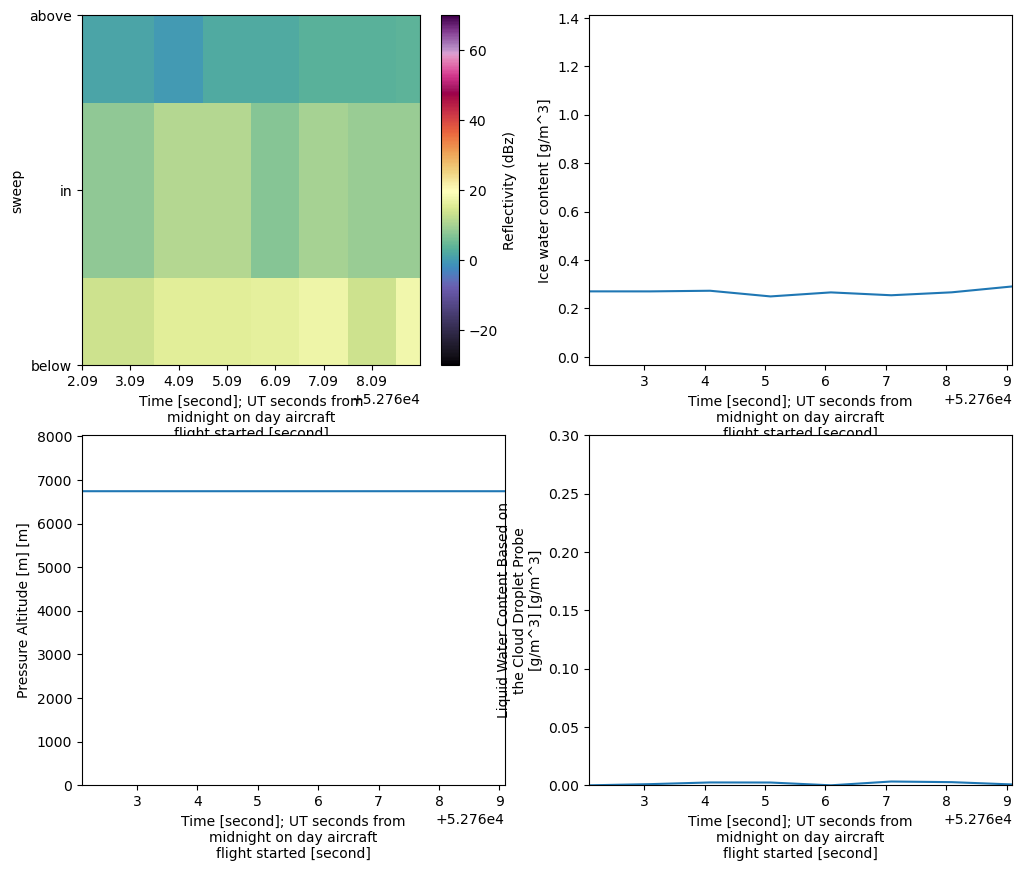

In [56]:
# Time calculator 
#start_time = ((3600 * 14) + (60 * 35) + 6)
#end_time = ((3600 * 14) + (60 * 37) + 27)
#start_time = cloud_micro_radar.Time.data[6315]
ds = xr.open_dataset('flight_data/11_05_20_Radar.nc')
start_time = ds.Time.data[6315]
end_time = start_time + 7

fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

ds.Radar_Reflectivity.plot(x = 'Time', 
                            ax = axs[0, 0],
                            cmap = 'ChaseSpectral', 
                            vmin = -30, 
                            vmax = 70, 
                            cbar_kwargs={"label": "Reflectivity (dBz)"})
axs[0, 0].set_xlim(start_time, end_time)

ds.IWC.plot(ax = axs[0, 1])
axs[0,1].set_xlim(start_time, end_time)

ds.Press_Alt.plot(ax = axs[1, 0])
axs[1, 0].set_xlim(start_time, end_time)

ds.CDP_LWC.plot(ax = axs[1, 1])
axs[1, 1].set_xlim(start_time, end_time)
axs[1, 1].set_ylim(0, .3)

axs[0, 0].set_xticks(np.arange(start_time, end_time, 1))
plt.show()

In [305]:
vert_radar_profile.corrected_reflectivity_horizontal.height.data[0]

np.float64(641.2780443634838)

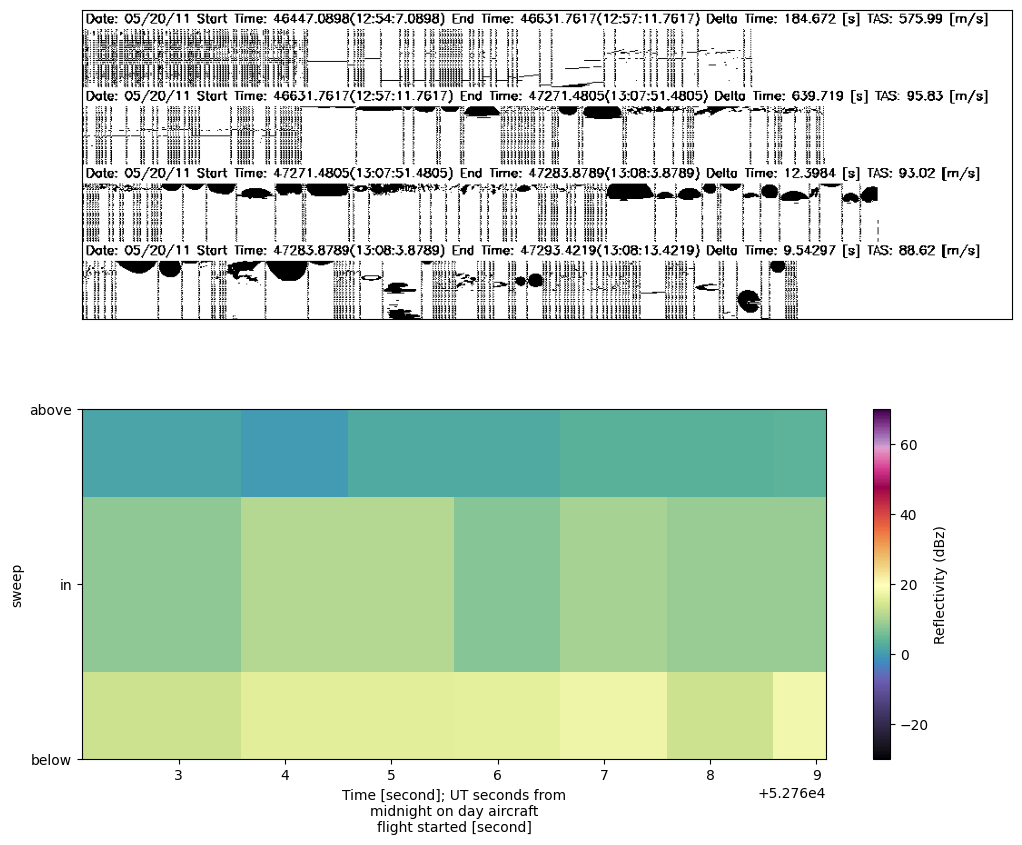

In [4]:
#=========================================
# Below is code designed to read in output
# netcdf file from code above along with 
# particle images to compare radar 
# reflectivity with particles observed 
#=========================================
ds = xr.open_dataset('flight_data/11_05_20_Radar.nc')
start_time = ds.Time.data[6315]
end_time = start_time + 7

# Initial read in of all possible CIP images
with os.scandir('flight_data/CIP_images/') as entries:
    cip_files_data = list(entries)

# Convert file directory to indexable list
cip_files = []
for x in cip_files_data:
    cip_files.append(x.name)

# Initial read in of all possible 2DC images 
with os.scandir('flight_data/CIP_Images/') as entries:
    twodc_files_data = list(entries)

# Convert file directory to indexable list
twodc_files = []
for x in twodc_files_data:
    twodc_files.append(x.name)


image_file = twodc_files[0]
image = plt.imread(f'flight_data/CIP_Images/{image_file}')

fig, axs = plt.subplots(nrows=2, ncols=1, figsize=(12, 10))

axs[0].imshow(image)
axs[0].set_xticks([])
axs[0].set_yticks([])

ds.Radar_Reflectivity.plot(x = 'Time', 
                            ax = axs[1],
                            cmap = 'ChaseSpectral', 
                            vmin = -30, 
                            vmax = 70, 
                            cbar_kwargs={"label": "Reflectivity (dBz)"})

axs[1].set_xlim(start_time, end_time)

plt.show()

In [ ]:
ds.close()

In [3]:
cloud_micro = xr.open_dataset('flight_data/11_05_20_Radar.nc')

In [ ]:
forward = widgets.Button(description=">")
backward = widgets.Button(description="<")
output = widgets.Output()

counter = 6315

def forward_button_click(b):
    with output:
        global counter
        counter += 1
        print(cloud_micro.Radar_Reflectivity.data[counter])
        print(counter)
        
def backward_button_click(b):
    with output:
        global counter
        counter -= 1
        print(cloud_micro.Radar_Reflectivity.data[counter])
        print(counter)
        
forward.on_click(forward_button_click)
backward.on_click(backward_button_click)
display(widgets.HBox([backward, forward]), output)

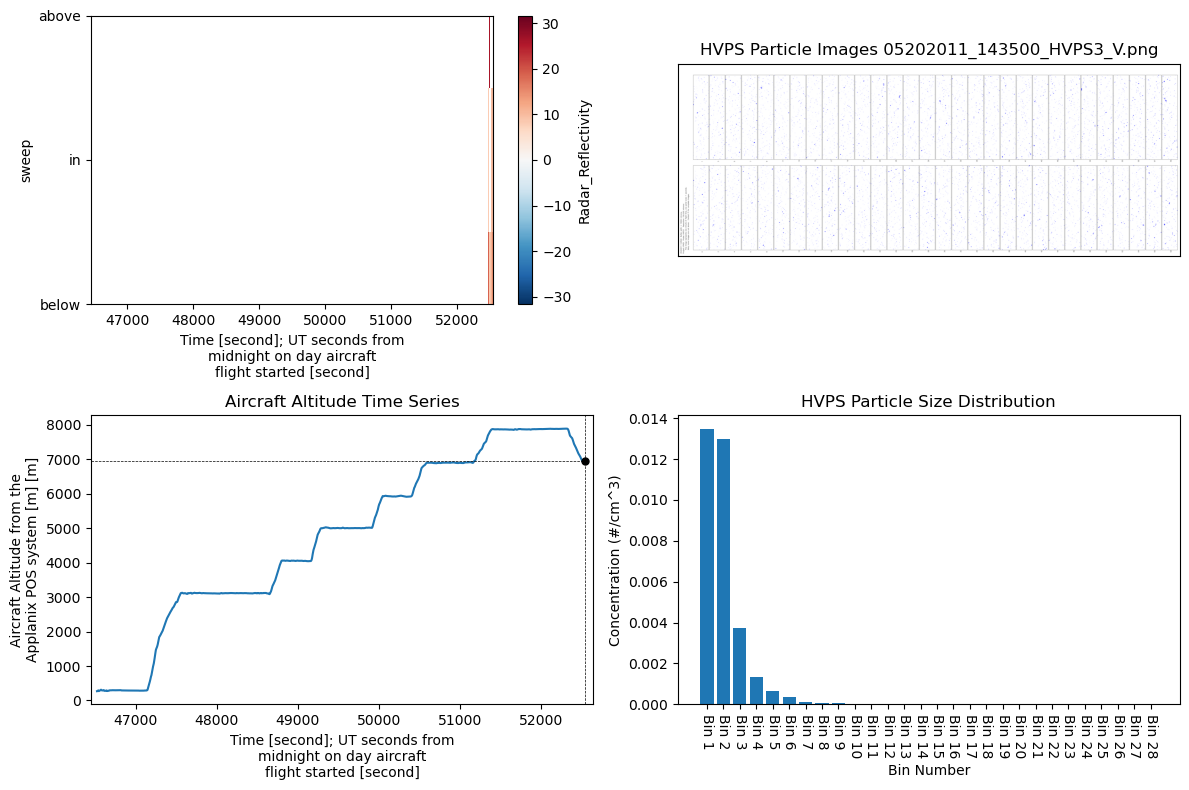

In [33]:
#=====================================
# This code is meant to generate
# a display of aircraft and radar data
#=====================================

# Read in cloud microphysics with radar scan data file 
cloud_micro = xr.open_dataset('flight_data/11_05_20_Radar.nc')

# Axis definition for plotting 
fig, axs = plt.subplots(nrows=2, ncols=2, figsize=(12, 8))
time = 6100

# Altitude time series plot
cloud_micro.POS_Alt[0:time].plot(ax = axs[1, 0])
axs[1, 0].axvline(x=cloud_micro.Time.data[time], color='black', linestyle = '--', linewidth = .5)
axs[1, 0].plot([cloud_micro.Time.data[0], cloud_micro.Time.data[time]], [cloud_micro.POS_Alt.data[time], cloud_micro.POS_Alt.data[time]], color = 'black', linestyle = '--', linewidth = .5)
axs[1, 0].plot(cloud_micro.Time.data[time], cloud_micro.POS_Alt.data[time], color = 'black', marker = 'o', markersize = 5)
axs[1, 0].set_title('Aircraft Altitude Time Series')
axs[1, 0].set_xlim([cloud_micro.Time.data[0], cloud_micro.Time.data[time] + 100])

# HVPS particle size distribution plot
hvps_data = [cloud_micro.HVPS_Ch1.data[time], cloud_micro.HVPS_Ch2.data[time], cloud_micro.HVPS_Ch3.data[time], cloud_micro.HVPS_Ch4.data[time], 
             cloud_micro.HVPS_Ch5.data[time], cloud_micro.HVPS_Ch6.data[time], cloud_micro.HVPS_Ch7.data[time], cloud_micro.HVPS_Ch8.data[time],
             cloud_micro.HVPS_Ch9.data[time], cloud_micro.HVPS_Ch10.data[time], cloud_micro.HVPS_Ch11.data[time], cloud_micro.HVPS_Ch12.data[time],
             cloud_micro.HVPS_Ch13.data[time], cloud_micro.HVPS_Ch14.data[time], cloud_micro.HVPS_Ch15.data[time], cloud_micro.HVPS_Ch16.data[time],
             cloud_micro.HVPS_Ch17.data[time], cloud_micro.HVPS_Ch18.data[time], cloud_micro.HVPS_Ch19.data[time], cloud_micro.HVPS_Ch20.data[time],
             cloud_micro.HVPS_Ch21.data[time], cloud_micro.HVPS_Ch22.data[time], cloud_micro.HVPS_Ch23.data[time], cloud_micro.HVPS_Ch24.data[time],
             cloud_micro.HVPS_Ch25.data[time], cloud_micro.HVPS_Ch26.data[time], cloud_micro.HVPS_Ch27.data[time], cloud_micro.HVPS_Ch28.data[time]]  

# Bin name descriptions
hvps_desc = ['Bin 1','Bin 2', 'Bin 3', 'Bin 4', 
             'Bin 5', 'Bin 6', 'Bin 7', 'Bin 8', 
             'Bin 9', 'Bin 10', 'Bin 11', 'Bin 12', 
             'Bin 13', 'Bin 14', 'Bin 15', 'Bin 16', 
             'Bin 17', 'Bin 18', 'Bin 19', 'Bin 20', 
             'Bin 21', 'Bin 22', 'Bin 23', 'Bin 24', 
             'Bin 25', 'Bin 26', 'Bin 27', 'Bin 28']

# Plotting of HVPS PSD data 
axs[1, 1].bar(hvps_desc, hvps_data)
axs[1, 1].tick_params(axis='x', labelrotation=-90)
axs[1, 1].set_ylabel('Concentration (#/cm^3)')
axs[1, 1].set_xlabel('Bin Number')
axs[1, 1].set_title('HVPS Particle Size Distribution')

# Reading in and finding of appropriate HVPS particle image file 
with os.scandir('flight_data/HVPS3_Images/') as entries:
    hvps_files = list(entries)

hvps_files_list = []
for entry in hvps_files:
    hvps_files_list.append((int(entry.name[9:15][0:2]) * 3600) + (int(entry.name[9:15][2:4]) * 60) + int(entry.name[9:15][4:6]))

# Find nearest file to time that is being displayed
hvps_files_list = np.array(hvps_files_list)

for file in hvps_files_list:
    if file < cloud_micro.Time.data[time]:
        min_file = file
        
file_name = hvps_files[np.where(hvps_files_list == min_file)[0][0]]

# Read in the appropriate image 
image = plt.imread(f'flight_data/HVPS3_Images/{file_name.name}')
rotated_img = np.rot90(image, k=1)

# Display image 
axs[0, 1].imshow(rotated_img)
axs[0, 1].set_xticks([])
axs[0, 1].set_yticks([])
axs[0, 1].set_title(f'HVPS Particle Images {file_name.name}')

cloud_micro.Radar_Reflectivity.plot(ax = axs[0, 0], 
                                   x = 'Time')
axs[0, 0].set_xlim([cloud_micro.Time.data[0], cloud_micro.Time.data[time]])

plt.tight_layout()
plt.show()

In [7]:
# Find the closest in time radar file for display of PPI with flight leg overlayed 

#plt.plot(cit_lon[min(air_radar_list[x]):y], cit_lat[min(air_radar_list[x]):y])
print(cloud_micro.POS_Lat.data[time])

36.554146
